In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import tifffile  # type: ignore
except Exception:
    tifffile = None

try:
    import rasterio  # type: ignore
except Exception:
    rasterio = None


ALLOWED_SUFFIXES = {".npy", ".tif", ".tiff"}


def load_multiband_array(path: Path) -> np.ndarray:
    # Load .npy/.tif/.tiff files as float32 arrays with TIFF fallback logic.
    suffix = path.suffix.lower()
    if suffix == ".npy":
        arr = np.load(path)
    elif suffix in {".tif", ".tiff"}:
        arr = None
        errors = []
        if tifffile is not None:
            try:
                arr = tifffile.imread(path)
            except Exception as e:
                errors.append(f"tifffile: {e}")
        if arr is None and rasterio is not None:
            try:
                with rasterio.open(path) as src:
                    arr = src.read()  # CHW
            except Exception as e:
                errors.append(f"rasterio: {e}")
        if arr is None:
            raise RuntimeError(
                "Unable to read TIFF. Install tifffile+imagecodecs or rasterio. "
                + " | ".join(errors)
            )
    else:
        raise ValueError(f"Unsupported file type: {path}")

    return np.asarray(arr, dtype=np.float32)


def as_hwc(arr: np.ndarray) -> np.ndarray:
    # Convert CHW arrays to HWC when needed.
    if arr.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {arr.shape}")

    # Typical CHW case: channels first and square spatial dims.
    if arr.shape[1] == arr.shape[2] and arr.shape[0] != arr.shape[1]:
        return np.moveaxis(arr, 0, -1)

    # Likely CHW non-square case (small channel count, larger spatial dims).
    if arr.shape[0] <= 16 and arr.shape[1] > 32 and arr.shape[2] > 32:
        return np.moveaxis(arr, 0, -1)

    return arr


def normalize_for_display(x: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    finite = np.isfinite(x)
    if not finite.any():
        return np.zeros_like(x, dtype=np.float32)
    lo, hi = np.percentile(x[finite], [p_low, p_high])
    if hi - lo < 1e-6:
        return np.zeros_like(x, dtype=np.float32)
    return np.clip((x - lo) / (hi - lo + 1e-6), 0.0, 1.0)


def first_supported_file(folder: Path) -> Path | None:
    if not folder.exists():
        return None
    files = sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in ALLOWED_SUFFIXES])
    return files[0] if files else None


def print_array_summary(title: str, path: Path, arr_hwc: np.ndarray):
    p01, p99 = np.percentile(arr_hwc[np.isfinite(arr_hwc)], [1, 99])
    print(f"\n{title}")
    print(f"  file: {path}")
    print(f"  shape (H, W, C): {arr_hwc.shape}")
    print(f"  dtype: {arr_hwc.dtype}")
    print(
        f"  value range: [{float(np.nanmin(arr_hwc)):.4f}, {float(np.nanmax(arr_hwc)):.4f}] "
        f"(p01={float(p01):.4f}, p99={float(p99):.4f})"
    )


def _pca_projection(arr_hwc: np.ndarray, max_samples: int = 20000) -> tuple[np.ndarray, float]:
    h, w, c = arr_hwc.shape
    if c < 3:
        rgb = np.repeat(arr_hwc[..., :1], 3, axis=-1)
        return normalize_for_display(rgb), float("nan")

    x = arr_hwc.reshape(-1, c).astype(np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    if x.shape[0] > max_samples:
        idx = np.random.default_rng(0).choice(x.shape[0], max_samples, replace=False)
        xs = x[idx]
    else:
        xs = x

    mu = xs.mean(axis=0, keepdims=True)
    xc = xs - mu
    cov = (xc.T @ xc) / max(xs.shape[0] - 1, 1)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    comps = eigvecs[:, :3]
    explained = float(eigvals[:3].sum() / (eigvals.sum() + 1e-12))

    z = (x - mu) @ comps
    z = z.reshape(h, w, 3)
    rgb = normalize_for_display(z, p_low=1, p_high=99)
    return rgb, explained


def _value_hist_sample(arr_hwc: np.ndarray, max_values: int = 200000) -> np.ndarray:
    v = arr_hwc.reshape(-1).astype(np.float32)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.array([0.0], dtype=np.float32)
    if v.size > max_values:
        idx = np.random.default_rng(1).choice(v.size, max_values, replace=False)
        v = v[idx]
    return v


def show_embedding_overview(
    arr_hwc: np.ndarray,
    title: str,
    max_hist_values: int = 200000,
    max_pca_samples: int = 20000,
):
    """
    Diagnostic overview for embedding tensors in HWC format.

    Panels:
      1) PCA RGB projection
      2) L2 norm across channels
      3) Cosine similarity to centroid
      4) Global scalar value histogram (all H*W*C values mixed)

    Parameters
    ----------
    arr_hwc : np.ndarray
        Embedding tensor with shape (H, W, C)
    title : str
        Figure title
    max_hist_values : int
        Max number of scalar values used in global histogram
    max_pca_samples : int
        Max number of samples used for PCA estimation
    """
    if arr_hwc.ndim != 3:
        raise ValueError(f"Expected arr_hwc with shape (H, W, C), got {arr_hwc.shape}")

    h, w, c = arr_hwc.shape
    if c < 1:
        raise ValueError(f"Expected at least 1 channel, got {c}")

    arr_hwc = np.asarray(arr_hwc, dtype=np.float32)
    x = arr_hwc.reshape(-1, c)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    # --- PCA projection
    pca_rgb, pca_top3 = _pca_projection(arr_hwc, max_samples=max_pca_samples)

    # --- L2 norm map
    norm_map = np.linalg.norm(arr_hwc, axis=-1)

    # --- Cosine similarity to centroid
    centroid = x.mean(axis=0)
    centroid_norm = float(np.linalg.norm(centroid) + 1e-8)
    x_norm = np.linalg.norm(x, axis=1) + 1e-8
    cos_sim = (x @ centroid) / (x_norm * centroid_norm)
    cos_map = cos_sim.reshape(h, w)

    # --- Global histogram values (all channels mixed)
    hist_values = _value_hist_sample(arr_hwc, max_values=max_hist_values)

    # Layout: single row with the 4 main diagnostics
    fig, axes = plt.subplots(1, 4, figsize=(17, 4.8))
    axes = np.atleast_1d(axes)

    interpolation = "nearest" if min(h, w) <= 32 else "none"

    axes[0].imshow(pca_rgb, interpolation=interpolation)
    if np.isfinite(pca_top3):
        axes[0].set_title(f"PCA RGB (top3={pca_top3 * 100:.1f}% var)")
    else:
        axes[0].set_title("RGB-like projection")
    axes[0].axis("off")

    im1 = axes[1].imshow(norm_map, cmap="magma", interpolation=interpolation)
    axes[1].set_title("L2 norm across channels")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(cos_map, cmap="coolwarm", vmin=-1, vmax=1, interpolation=interpolation)
    axes[2].set_title("Cosine similarity to centroid")
    axes[2].axis("off")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    axes[3].hist(hist_values, bins=80, color="slategray", alpha=0.9)
    axes[3].set_title("Global scalar value distribution")
    axes[3].set_xlabel("embedding scalar value")
    axes[3].set_ylabel("count")

    fig.suptitle(f"{title}\n(H={h}, W={w}, C={c})", fontsize=14)
    plt.tight_layout()
    plt.show()


def show_label_overview(lbl_hwc: np.ndarray, title: str):
    if lbl_hwc.shape[-1] < 4:
        raise ValueError(f"Expected 4 label channels, got shape {lbl_hwc.shape}")

    building = lbl_hwc[..., 0]
    vegetation = lbl_hwc[..., 1]
    water = lbl_hwc[..., 2]
    ndsm = lbl_hwc[..., 3]

    pct_scale = 100.0 if max(float(np.nanmax(building)), float(np.nanmax(vegetation)), float(np.nanmax(water))) > 1.0 else 1.0
    pct_label = "%" if pct_scale > 1.0 else "fraction"

    fig, axes = plt.subplots(1, 4, figsize=(10, 3))

    im0 = axes[0].imshow(building, cmap="Reds")
    axes[0].set_title(f"Building ({pct_label})")
    axes[0].axis("off")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(vegetation, cmap="Greens")
    axes[1].set_title(f"Vegetation ({pct_label})")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(water, cmap="Blues")
    axes[2].set_title(f"Water ({pct_label})")
    axes[2].axis("off")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    im3 = axes[3].imshow(ndsm, cmap="viridis")
    axes[3].set_title("Relative Height (nDSM)")
    axes[3].axis("off")
    fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()



Reference labels
  file: data\terramind_s1_train_test_split\test\labels\label_0001_BE_2023.tif
  shape (H, W, C): (256, 256, 4)
  dtype: float32
  value range: [0.0000, 27.2048] (p01=0.0000, p99=16.9045)


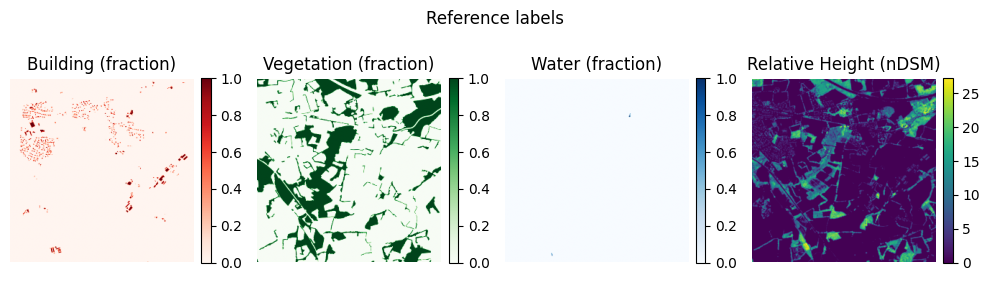


Predicted labels
  file: runs\test_terramind_s1_decoder_residual\predictions_train\pred_0001_BE.npy
  shape (H, W, C): (256, 256, 4)
  dtype: float32
  value range: [-3.1961, 13.0519] (p01=-0.2796, p99=8.3840)


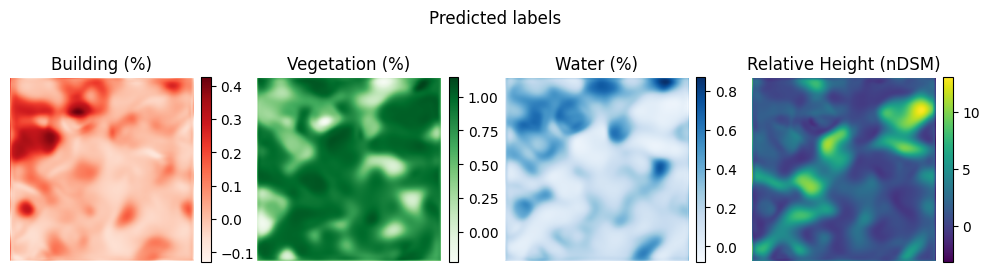

In [17]:
# One example per entry (first image from each dataset)
example_specs = [
    ("Reference labels", 
     "data/terramind_s1_train_test_split/test/labels", 
     "labels"),
    ("Predicted labels",
     "runs/test_terramind_s1_decoder_residual/predictions_train", 
     "labels"),
]

for title, folder, kind in example_specs:
    folder = Path(folder)
    sample_file = first_supported_file(folder)

    if sample_file is None:
        print(f"\n[missing] No supported files found in {folder}")
        continue

    arr = load_multiband_array(sample_file)
    arr_hwc = as_hwc(arr)
    print_array_summary(title, sample_file, arr_hwc)

    if kind == "labels":
        show_label_overview(arr_hwc, title)
    # else:
    #     show_embedding_overview(arr_hwc, title)

